# Time Series Naive
**Author:** Alejandro Orellana

**Date:** Feburary 6, 2026

**Data Source:** Chicago Energy Benchmarking Dataset (2014-2023) - City of Chicago Open Data Portal  

In [1]:
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from utils.data_utils import load_data, load_neighborhood_geojson
from utils.fix_effect_utils import (
    check_var_count_for_var,
    map_community,
    ols_compare_and_pred_plot,
    prepared_dataframe,
)

geojson_data = load_neighborhood_geojson()
analysis_df = prepared_dataframe(load_data())
target_col = "Site EUI (kBtu/sq ft)"
analysis_df["geo_mapped_name"] = analysis_df["Community Area"].apply(map_community)
analysis_df = analysis_df.sort_values(["ID", "Data Year"])

2026-02-16 02:05:47,095 [INFO] Loading GeoJSON from: /project/data/chicago_geo/neighborhood_chi.geojson
2026-02-16 02:05:47,132 [INFO] Loaded 98 features
2026-02-16 02:05:47,646 [INFO] ✅ COVID Impact Category assignment (with 'Other' group) complete.
2026-02-16 02:05:47,648 [INFO] Category counts:
COVID Impact Category
Other                   505
Permanent              1813
Stable/Increased       7470
Temporary/Rebounded    1716


# Dropping all the unique buildings with at least 1 missing Site EUI

In [2]:
missing_counts = analysis_df.groupby("ID").agg(
    Missing_Data=("Site EUI (kBtu/sq ft)", lambda x: x.isna().sum())
)

dropping_list = missing_counts[missing_counts["Missing_Data"] > 0].index
model_data = analysis_df.copy()
model_data = model_data.sort_values(["ID", "Data Year"])
model_data = model_data.drop(model_data[model_data["ID"].isin(dropping_list)].index)

In [3]:
metrics = analysis_df.columns
index_col = "Data Year"
check_var_count_for_var(metrics, index_col, model_data)

Data Year: 0 missing rows (0.00%)
Missing data (NA) Data Year by Year:
# of Buildings with at least 1 missing of Data Year: 0 (0.00%%) buildings 

ID: 0 missing rows (0.00%)
Missing data (NA) ID by Year:
# of Buildings with at least 1 missing of ID: 0 (0.00%%) buildings 

Property Name: 0 missing rows (0.00%)
Missing data (NA) Property Name by Year:
# of Buildings with at least 1 missing of Property Name: 0 (0.00%%) buildings 

Address: 0 missing rows (0.00%)
Missing data (NA) Address by Year:
# of Buildings with at least 1 missing of Address: 0 (0.00%%) buildings 

ZIP Code: 0 missing rows (0.00%)
Missing data (NA) ZIP Code by Year:
# of Buildings with at least 1 missing of ZIP Code: 0 (0.00%%) buildings 

Community Area: 0 missing rows (0.00%)
Missing data (NA) Community Area by Year:
# of Buildings with at least 1 missing of Community Area: 0 (0.00%%) buildings 

Primary Property Type: 0 missing rows (0.00%)
Missing data (NA) Primary Property Type by Year:
# of Buildings with at lea

### Filling missing data from the previous year and making other columns

In [4]:
filling_cols = ["Gross Floor Area - Buildings (sq ft)", "Year Built"]
for col in filling_cols:
    model_data[col] = analysis_df.groupby("ID")[col].transform(
        lambda x: x.ffill().bfill()
    )

model_data["Building_Age"] = model_data["Data Year"] - model_data["Year Built"]

In [5]:
remove_year = 2016
cut_off_year = 2023
model_data["Site_EUI_Lag1"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(1)
model_data["Site_EUI_Lag2"] = model_data.groupby("ID")["Site EUI (kBtu/sq ft)"].shift(2)
model_data["Momentum"] = model_data["Site_EUI_Lag1"] - model_data["Site_EUI_Lag2"]

model_data = model_data[model_data["Data Year"] != remove_year]
train_df = model_data[model_data["Data Year"] < cut_off_year]
test_df = model_data[model_data["Data Year"] == cut_off_year]
print(f"Training Samples: {len(train_df)} | Testing Samples: {len(test_df)}")
model_data[
    [
        "Data Year",
        "ID",
        "Year Built",
        "Building_Age",
        "Gross Floor Area - Buildings (sq ft)",
        "Site EUI (kBtu/sq ft)",
        "Site_EUI_Lag1",
        "Site_EUI_Lag2",
        "Momentum",
    ]
].head()

Training Samples: 7284 | Testing Samples: 1214


,Data Year,ID,Year Built,Building_Age,Gross Floor Area - Buildings (sq ft),Site EUI (kBtu/sq ft),Site_EUI_Lag1,Site_EUI_Lag2,Momentum
2543,2017,100001,1928.0,89.0,309056.0,182.6,190.4,NaN,NaN
28282,2018,100001,1928.0,90.0,309056.0,188.8,182.6,190.4,-7.8
20009,2019,100001,1928.0,91.0,309056.0,178.3,188.8,182.6,6.2
6268,2020,100001,1928.0,92.0,505417.0,175.0,178.3,188.8,-10.5
12826,2021,100001,1928.0,93.0,505417.0,171.0,175.0,178.3,-3.3


In [6]:
target_col = "Site EUI (kBtu/sq ft)"

exclude_cols = [target_col, "Site_EUI_Lag1"]
q_feature_cols = [
    "Site_EUI_Lag1",
    "Site_EUI_Lag2",
    "Momentum",
    "Gross Floor Area - Buildings (sq ft)",
    "# of Buildings",
    "Electricity Use (kBtu)",
    "Building_Age",
]
c_feature_cols = [
    "ZIP Code",
    "geo_mapped_name",
    "Primary Property Type",
    "COVID Impact Category",
    "Data Year",
]
full_var = []
for q in q_feature_cols:
    full_var.append(f"Q('{q}')")
for c in c_feature_cols:
    full_var.append(f"C(Q('{c}'))")

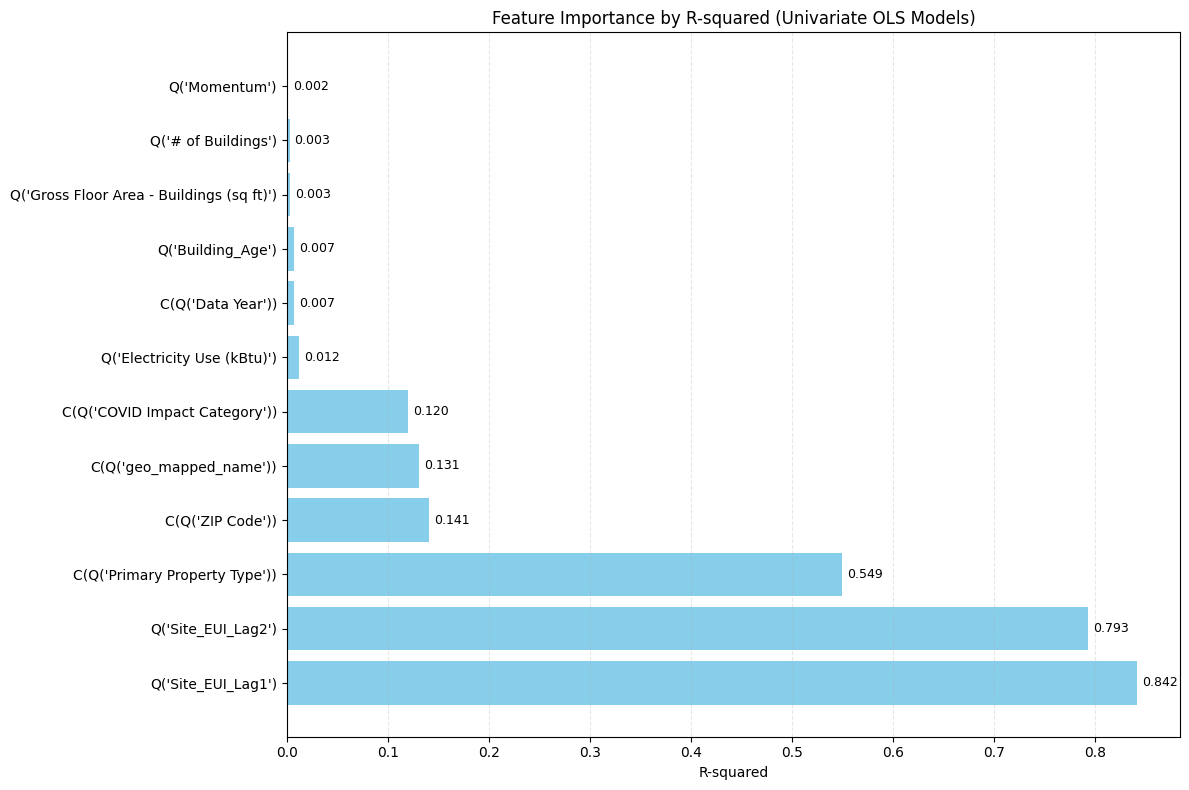

In [7]:
r_squared_dict = {}

for feature in full_var:
    try:
        formula = f"Q('{target_col}') ~ {feature}"

        model = smf.ols(formula, data=train_df).fit()

        r_squared_dict[feature] = model.rsquared
    except Exception as e:
        print(f"Error with feature '{feature}': {e}")
        r_squared_dict[feature] = 0

sorted_r2 = sorted(r_squared_dict.items(), key=lambda x: x[1], reverse=True)
features_sorted = [item[0] for item in sorted_r2]
r2_values_sorted = [item[1] for item in sorted_r2]

plt.figure(figsize=(12, 8))
bars = plt.barh(features_sorted, r2_values_sorted, color="skyblue")

for bar, r2 in zip(bars, r2_values_sorted):
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{r2:.3f}",
        ha="left",
        va="center",
        fontsize=9,
    )

plt.xlabel("R-squared")
plt.title("Feature Importance by R-squared (Univariate OLS Models)")
plt.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.842
Model:                                    OLS   Adj. R-squared:                  0.842
Method:                         Least Squares   F-statistic:                 3.875e+04
Date:                        Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                                02:05:49   Log-Likelihood:                -32078.
No. Observations:                        7284   AIC:                         6.416e+04
Df Residuals:                            7282   BIC:                         6.417e+04
Df Model:                                   1                                         
Covariance Type:                    nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


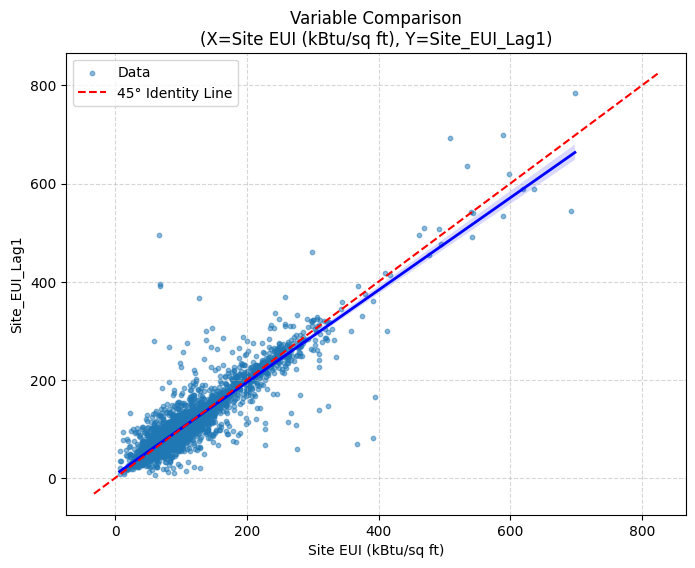

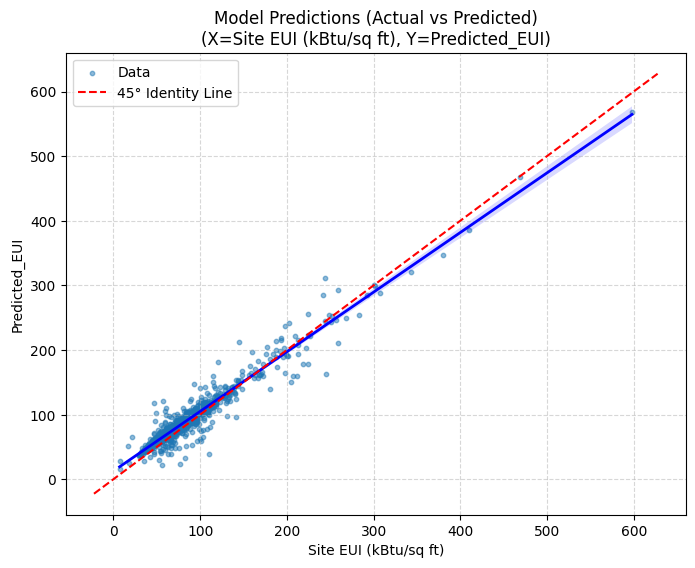

In [8]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ Q('Site_EUI_Lag1')"
x_var = "Site EUI (kBtu/sq ft)"
y_var = "Site_EUI_Lag1"
ols_compare_and_pred_plot(formula, x_var, y_var, model_data, train_df, test_df)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.549
Model:                                    OLS   Adj. R-squared:                  0.548
Method:                         Least Squares   F-statistic:                     340.0
Date:                        Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                                02:05:50   Log-Likelihood:                -35892.
No. Observations:                        7284   AIC:                         7.184e+04
Df Residuals:                            7257   BIC:                         7.202e+04
Df Model:                                  26                                         
Covariance Type:                    nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025    

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


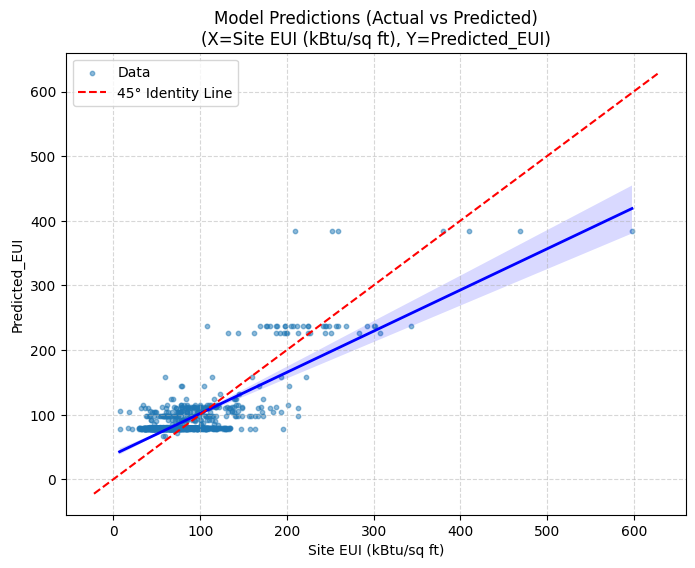

In [9]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ C(Q('Primary Property Type'))"
y_var = "Primary Property Type"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.141
Model:                                    OLS   Adj. R-squared:                  0.132
Method:                         Least Squares   F-statistic:                     17.10
Date:                        Mon, 16 Feb 2026   Prob (F-statistic):          5.85e-185
Time:                                02:05:50   Log-Likelihood:                -38242.
No. Observations:                        7284   AIC:                         7.662e+04
Df Residuals:                            7214   BIC:                         7.711e+04
Df Model:                                  69                                         
Covariance Type:                    nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


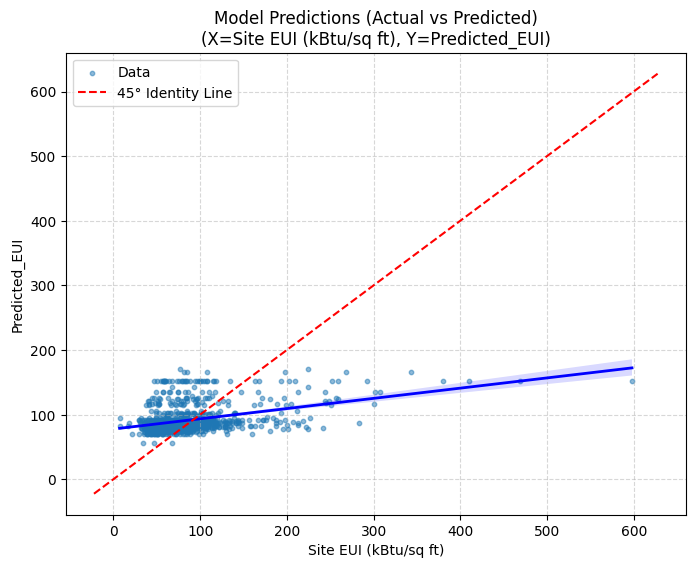

In [10]:
formula = "Q('Site EUI (kBtu/sq ft)') ~ C(Q('ZIP Code'))"
y_var = "ZIP Code"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

                                OLS Regression Results                                
Dep. Variable:     Q('Site EUI (kBtu/sq ft)')   R-squared:                       0.851
Model:                                    OLS   Adj. R-squared:                  0.851
Method:                         Least Squares   F-statistic:                     1540.
Date:                        Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                                02:05:50   Log-Likelihood:                -31849.
No. Observations:                        7284   AIC:                         6.375e+04
Df Residuals:                            7256   BIC:                         6.395e+04
Df Model:                                  27                                         
Covariance Type:                    nonrobust                                         
                                                                             coef    std err          t      P>|t|      [0.025    

/project/src/utils/fix_effect_utils.py:347: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data["Predicted_EUI"] = model.predict(test_data)


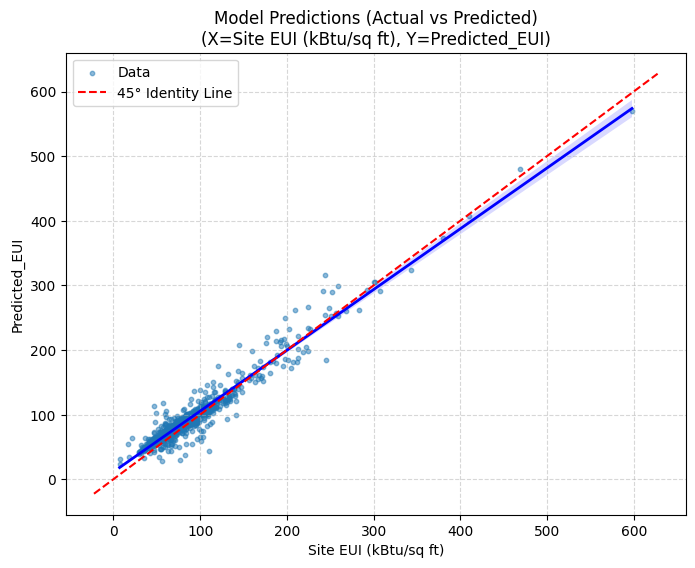

In [11]:
formula = (
    "Q('Site EUI (kBtu/sq ft)') ~ Q('Site_EUI_Lag1') + C(Q('Primary Property Type'))"
)
y_var = "Primary Property Type"
ols_compare_and_pred_plot(
    formula, x_var, y_var, model_data, train_df, test_df, Compare_show=False
)

dependent var: dif of next - avg of next year(site eui)

given a building is it higher or lower based on expectations
- Expectations: avg site eui of next year

- we care about predicting the delta of a buildings site eui change next year of the avg sit eui of next year

- fix effect: year, property type, combo(year, property type)